# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-002 |
| **Nama Eksperimen** | Exploratory Data Analysis (EDA) |
| **Dataset** | hour.csv (Bike Sharing Dataset — UCI ML Repository) |
| **Tujuan Notebook** | Menemukan pola, distribusi, dan hubungan antar feature |
| **Tanggal Pengerjaan** | 21 Juli 2026 |
| **Versi Notebook** | 1.0.0 |
| **Author** | GAKUSEI Najib |
| **Prasyarat** | EXP-001 Data Understanding (Selesai) |

---

## Daftar Isi

1. [Tujuan Eksperimen](#1-tujuan-eksperimen)
2. [Import Library](#2-import-library)
3. [Load Dataset](#3-load-dataset)
4. [Persiapan Data](#4-persiapan-data)
5. [Analisis Target (cnt)](#5-analisis-target-cnt)
6. [Analisis Time Series](#6-analisis-time-series)
7. [Analisis Feature Cuaca](#7-analisis-feature-cuaca)
8. [Analisis Feature Kategorikal](#8-analisis-feature-kategorikal)
9. [Analisis Korelasi](#9-analisis-korelasi)
10. [EDA Summary & Insight](#10-eda-summary--insight)
11. [Next Step](#11-next-step)

---

## 1. Tujuan Eksperimen

### Tujuan

Menemukan pola, tren, distribusi, hubungan antar feature, serta insight awal yang dapat digunakan untuk proses feature engineering dan modeling.

---

### Hipotesis

> Dataset memiliki pola musiman dan pola harian yang memengaruhi jumlah penyewaan sepeda.

---

### Output yang Diharapkan

- Grafik distribusi target `cnt`
- Visualisasi pola harian, mingguan, bulanan, dan musiman
- Analisis pengaruh cuaca terhadap penyewaan
- Correlation matrix antar feature
- Daftar feature penting untuk modeling
- Potensi feature engineering

---

### Aktivitas

| Kelompok | Analisis |
|----------|----------|
| **Target** | Distribusi, histogram, boxplot, skewness, outlier |
| **Time Series** | Tren harian, bulanan, tahunan, pola jam, weekday vs weekend |
| **Cuaca** | Suhu, kelembapan, kecepatan angin, kondisi cuaca |
| **Kategorikal** | Season, holiday, workingday, weekday |
| **Korelasi** | Heatmap, scatter plot |

---

### Acceptance Criteria

| Kriteria | Keterangan |
|----------|------------|
| Seluruh feature dianalisis | Semua kelompok feature memiliki minimal satu analisis |
| Target dianalisis | Distribusi dan pola `cnt` terdokumentasi |
| Insight minimal satu per kelompok feature | Ditulis pada Section 10 |
| Seluruh grafik diberi interpretasi | Komentar ditulis di bawah setiap grafik |

---

## 2. Import Library

Selain `pandas` dan `numpy`, pada notebook EDA dibutuhkan library visualisasi:

- **matplotlib** — library utama untuk plotting
- **seaborn** — library statistik visual berbasis matplotlib

Keduanya akan digunakan untuk menghasilkan visualisasi yang informatif dan mudah dibaca.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Konfigurasi
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Gaya visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

print('Library berhasil diimport.')
print(f'Versi pandas     : {pd.__version__}')
print(f'Versi numpy      : {np.__version__}')
print(f'Versi matplotlib : {plt.matplotlib.__version__}')
print(f'Versi seaborn    : {sns.__version__}')

Library berhasil diimport.
Versi pandas     : 2.3.3
Versi numpy      : 2.0.2
Versi matplotlib : 3.9.4
Versi seaborn    : 0.13.2


---

## 3. Load Dataset

Dataset yang digunakan adalah `hour.csv` yang telah divalidasi pada EXP-001.

In [2]:
# Definisikan path dataset
DATA_PATH = '../data/hour.csv'

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f'Dataset berhasil dimuat dari: {DATA_PATH}')
print(f'Dimensi: {df.shape[0]:,} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat dari: ../data/hour.csv
Dimensi: 17,379 baris x 17 kolom


---

## 4. Persiapan Data

Sebelum melakukan analisis visual, dilakukan beberapa persiapan awal:

1. Konversi kolom `dteday` dari string ke `datetime`.
2. Penambahan label teks untuk kolom kategorikal agar grafik lebih mudah dibaca.

> **Catatan:** Persiapan ini hanya untuk keperluan EDA. Transformasi resmi dilakukan pada EXP-003 Data Cleaning.

In [3]:
# Konversi dteday ke tipe datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Tambahkan label teks untuk kolom kategorikal (untuk keperluan visualisasi)
df['season_label']     = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
df['yr_label']         = df['yr'].map({0: '2011', 1: '2012'})
df['weathersit_label'] = df['weathersit'].map({
    1: 'Cerah',
    2: 'Berkabut',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
})
df['weekday_label'] = df['weekday'].map({
    0: 'Minggu', 1: 'Senin', 2: 'Selasa',
    3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'
})

print('Persiapan data selesai.')
print(f'Tipe dteday setelah konversi: {df["dteday"].dtype}')
print(f'Rentang tanggal: {df["dteday"].min().date()} s.d. {df["dteday"].max().date()}')

Persiapan data selesai.
Tipe dteday setelah konversi: datetime64[ns]
Rentang tanggal: 2011-01-01 s.d. 2012-12-31


---

## 5. Analisis Target (cnt)

Target prediksi adalah kolom `cnt` yang merepresentasikan total penyewaan sepeda per jam. Analisis ini mencakup distribusi, skewness, dan identifikasi outlier.

### 5.1 Statistik Deskriptif Target

In [4]:
# Statistik deskriptif target
stats = df['cnt'].describe()
skewness = df['cnt'].skew()
kurtosis = df['cnt'].kurtosis()
median   = df['cnt'].median()

print('=' * 45)
print('STATISTIK DESKRIPTIF TARGET: cnt')
print('=' * 45)
print(f'Jumlah Data  : {int(stats["count"]):,}')
print(f'Mean         : {stats["mean"]:.2f}')
print(f'Median       : {median:.2f}')
print(f'Std Dev      : {stats["std"]:.2f}')
print(f'Min          : {int(stats["min"])}')
print(f'Max          : {int(stats["max"])}')
print(f'Q1 (25%)     : {stats["25%"]:.2f}')
print(f'Q3 (75%)     : {stats["75%"]:.2f}')
print(f'IQR          : {stats["75%"] - stats["25%"]:.2f}')
print(f'Skewness     : {skewness:.4f}')
print(f'Kurtosis     : {kurtosis:.4f}')

STATISTIK DESKRIPTIF TARGET: cnt
Jumlah Data  : 17,379
Mean         : 189.46
Median       : 142.00
Std Dev      : 181.39
Min          : 1
Max          : 977
Q1 (25%)     : 40.00
Q3 (75%)     : 281.00
IQR          : 241.00
Skewness     : 1.2774
Kurtosis     : 1.4172


### 5.2 Distribusi Target (Histogram + KDE)

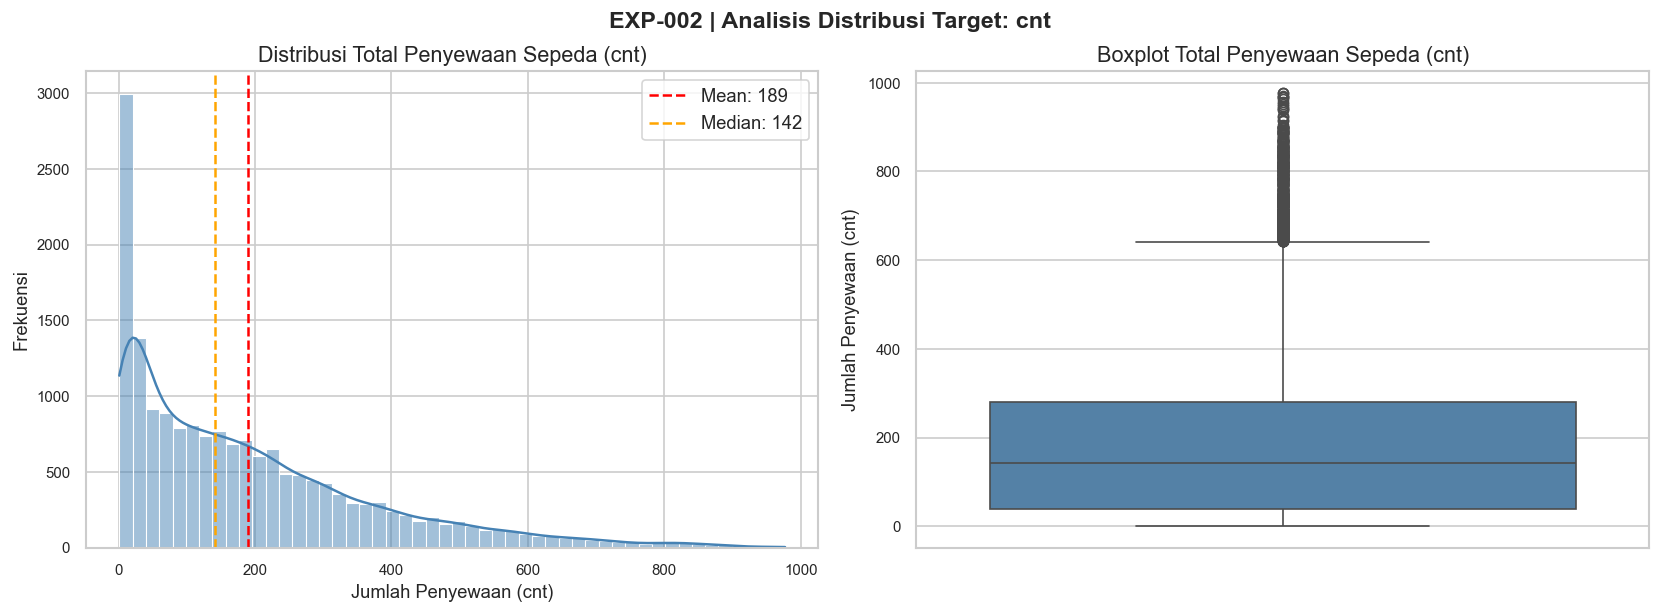

Grafik distribusi cnt tersimpan.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['cnt'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['cnt'].mean(), color='red', linestyle='--', label=f'Mean: {df["cnt"].mean():.0f}')
axes[0].axvline(df['cnt'].median(), color='orange', linestyle='--', label=f'Median: {df["cnt"].median():.0f}')
axes[0].set_title('Distribusi Total Penyewaan Sepeda (cnt)')
axes[0].set_xlabel('Jumlah Penyewaan (cnt)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['cnt'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot Total Penyewaan Sepeda (cnt)')
axes[1].set_ylabel('Jumlah Penyewaan (cnt)')

plt.tight_layout()
plt.suptitle('EXP-002 | Analisis Distribusi Target: cnt', fontsize=14, y=1.02, fontweight='bold')
plt.savefig('../data/eda_01_distribusi_cnt.png', bbox_inches='tight', dpi=120)
plt.show()
print('Grafik distribusi cnt tersimpan.')

**Interpretasi:**

- Distribusi `cnt` bersifat **positively skewed (right-skewed)**, dengan mayoritas data terkonsentrasi di nilai rendah dan ekor panjang ke kanan.
- Mean lebih tinggi dari median, mengonfirmasi adanya skewness positif.
- Terdapat outlier di sisi atas (terlihat pada boxplot). Jam-jam puncak dengan penyewaan sangat tinggi menyebabkan ekor distribusi memanjang ke kanan.
- Distribusi ini dapat dipertimbangkan untuk transformasi log pada tahap preprocessing.

### 5.3 Perbandingan Pengguna Casual vs Registered

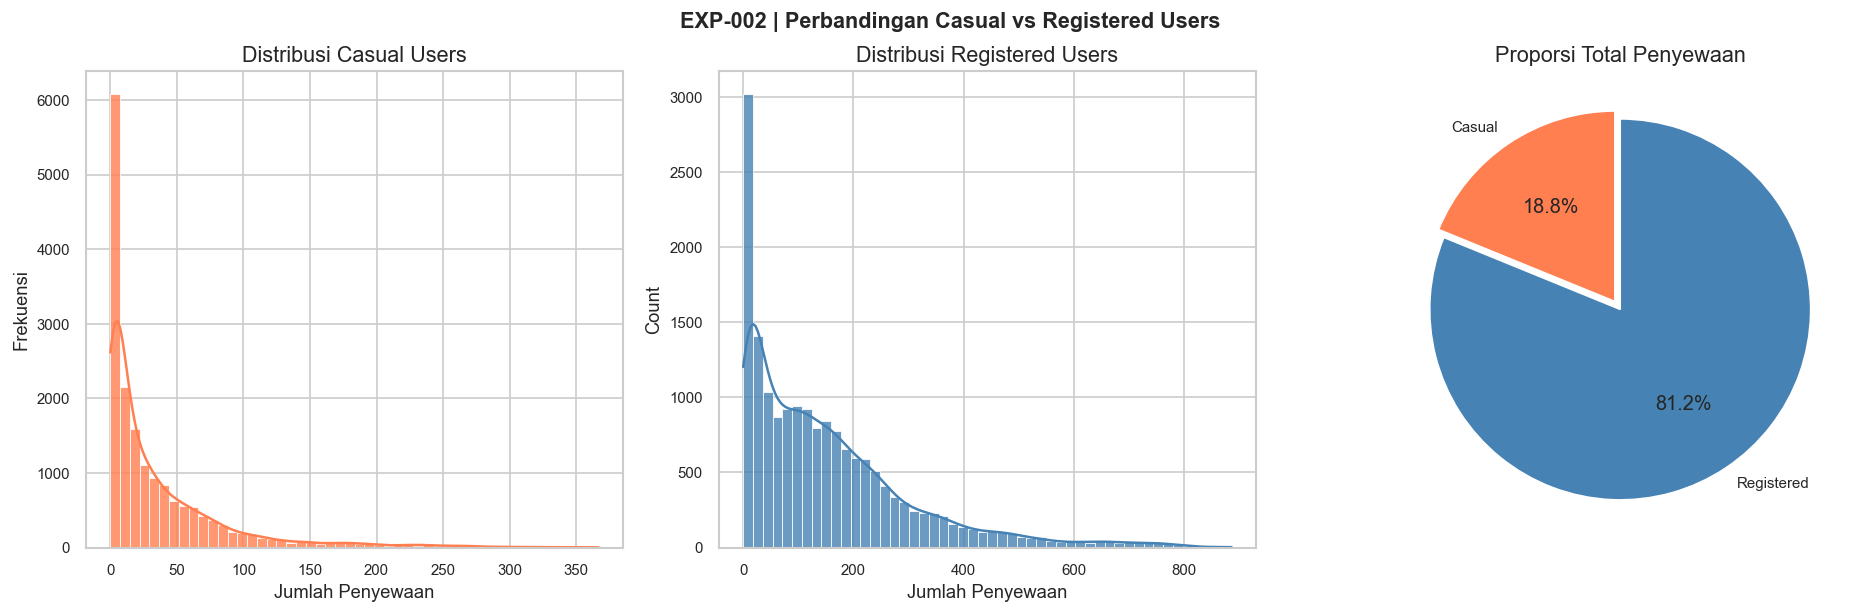

Total Casual     : 620,017 (18.8%)
Total Registered : 2,672,662 (81.2%)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi casual
sns.histplot(df['casual'], bins=50, kde=True, ax=axes[0], color='coral', alpha=0.8)
axes[0].set_title('Distribusi Casual Users')
axes[0].set_xlabel('Jumlah Penyewaan')
axes[0].set_ylabel('Frekuensi')

# Distribusi registered
sns.histplot(df['registered'], bins=50, kde=True, ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Distribusi Registered Users')
axes[1].set_xlabel('Jumlah Penyewaan')

# Proporsi total
total_casual     = df['casual'].sum()
total_registered = df['registered'].sum()
axes[2].pie(
    [total_casual, total_registered],
    labels=['Casual', 'Registered'],
    autopct='%1.1f%%',
    colors=['coral', 'steelblue'],
    startangle=90,
    explode=[0.05, 0]
)
axes[2].set_title('Proporsi Total Penyewaan')

plt.tight_layout()
plt.suptitle('EXP-002 | Perbandingan Casual vs Registered Users', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_02_casual_vs_registered.png', bbox_inches='tight', dpi=120)
plt.show()

pct_casual     = total_casual / (total_casual + total_registered) * 100
pct_registered = total_registered / (total_casual + total_registered) * 100
print(f'Total Casual     : {total_casual:,} ({pct_casual:.1f}%)')
print(f'Total Registered : {total_registered:,} ({pct_registered:.1f}%)')

**Interpretasi:**

- Pengguna terdaftar (**registered**) mendominasi total penyewaan dengan proporsi sekitar **80%**.
- Pengguna kasual (**casual**) hanya menyumbang sekitar **20%** dari total penyewaan.
- Distribusi `casual` jauh lebih skewed dibandingkan `registered`, menunjukkan bahwa pengguna kasual cenderung menyewa dalam jumlah kecil dan tidak rutin.
- Informasi ini berguna untuk analisis segmentasi perilaku pengguna pada EDA lanjutan.

---

## 6. Analisis Time Series

Bagian ini menganalisis pola penyewaan sepeda dari perspektif waktu.

### 6.1 Tren Harian (Daily Trend)

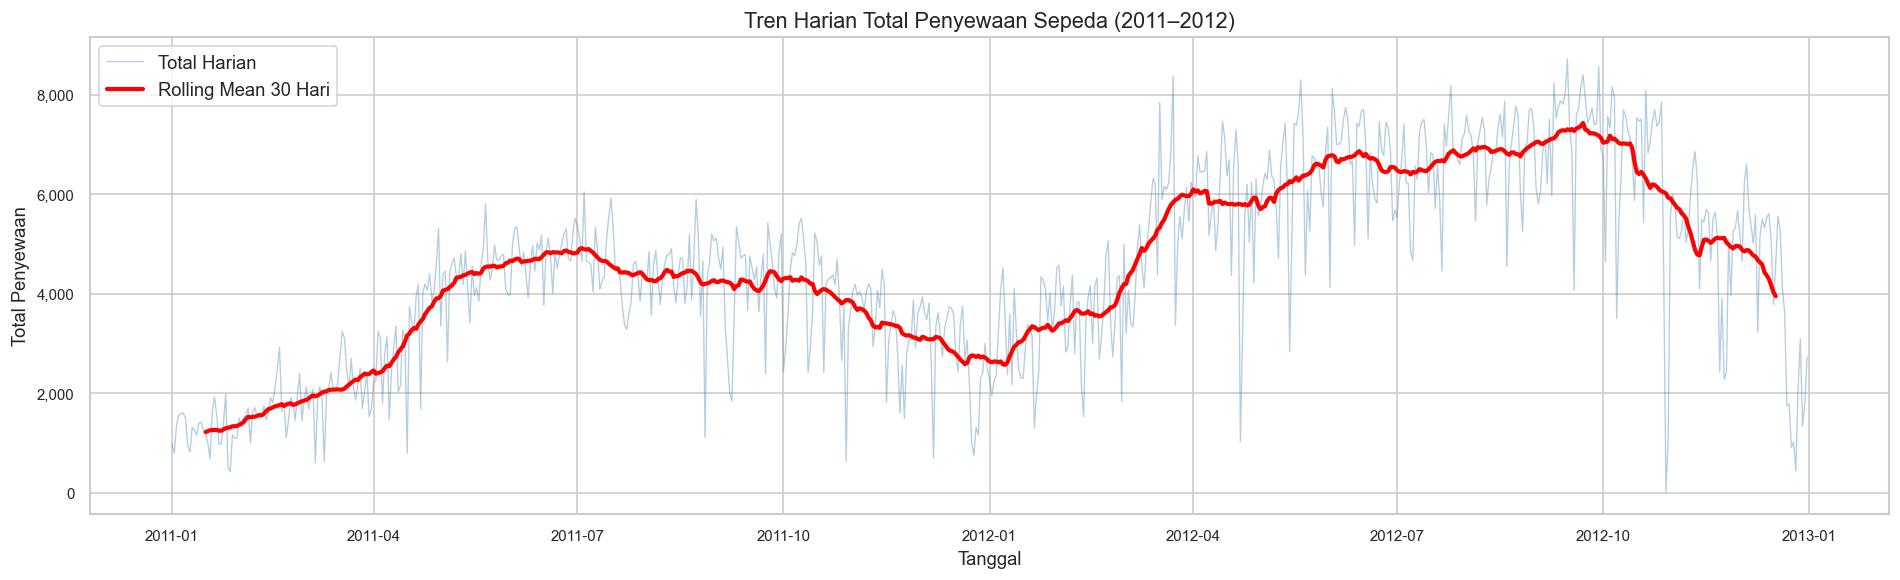

In [7]:
# Aggregasi total penyewaan per hari
df_daily = df.groupby('dteday')['cnt'].sum().reset_index()
df_daily.columns = ['tanggal', 'total_sewa']

# Rolling average 30 hari
df_daily['rolling_30'] = df_daily['total_sewa'].rolling(window=30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_daily['tanggal'], df_daily['total_sewa'],
        alpha=0.4, color='steelblue', linewidth=0.8, label='Total Harian')
ax.plot(df_daily['tanggal'], df_daily['rolling_30'],
        color='red', linewidth=2.5, label='Rolling Mean 30 Hari')

ax.set_title('Tren Harian Total Penyewaan Sepeda (2011–2012)')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Total Penyewaan')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/eda_03_tren_harian.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Terlihat **tren peningkatan** jumlah penyewaan dari 2011 ke 2012, menunjukkan pertumbuhan popularitas bike sharing.
- Terdapat **pola musiman yang jelas**: penyewaan meningkat di pertengahan tahun (musim panas/gugur) dan menurun di awal dan akhir tahun (musim dingin/semi).
- Rolling mean 30 hari mengonfirmasi pola seasonal yang konsisten selama dua tahun.

### 6.2 Pola Per Jam (Hourly Pattern)

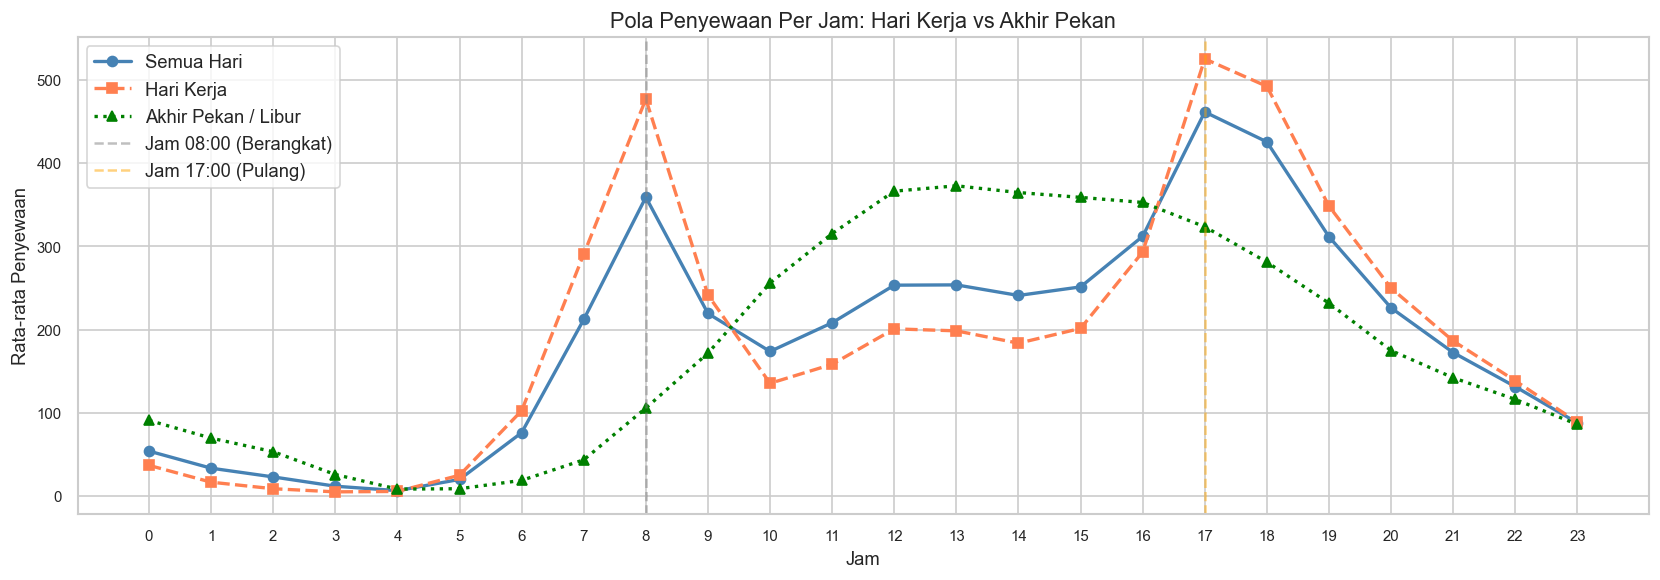

Jam puncak (hari kerja): 17:00 (525.3 rata-rata)
Jam puncak (libur): 13:00 (372.7 rata-rata)


In [8]:
# Rata-rata penyewaan per jam
df_hourly_all        = df.groupby('hr')['cnt'].mean().reset_index()
df_hourly_workingday = df[df['workingday'] == 1].groupby('hr')['cnt'].mean().reset_index()
df_hourly_holiday    = df[df['workingday'] == 0].groupby('hr')['cnt'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_hourly_all['hr'], df_hourly_all['cnt'],
        marker='o', linewidth=2, label='Semua Hari', color='steelblue')
ax.plot(df_hourly_workingday['hr'], df_hourly_workingday['cnt'],
        marker='s', linewidth=2, label='Hari Kerja', color='coral', linestyle='--')
ax.plot(df_hourly_holiday['hr'], df_hourly_holiday['cnt'],
        marker='^', linewidth=2, label='Akhir Pekan / Libur', color='green', linestyle=':')

# Anotasi jam puncak
jam_puncak_workday = df_hourly_workingday.loc[df_hourly_workingday['cnt'].idxmax(), 'hr']
ax.axvline(x=8, color='gray', linestyle='--', alpha=0.5, label='Jam 08:00 (Berangkat)')
ax.axvline(x=17, color='orange', linestyle='--', alpha=0.5, label='Jam 17:00 (Pulang)')

ax.set_title('Pola Penyewaan Per Jam: Hari Kerja vs Akhir Pekan')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Penyewaan')
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../data/eda_04_pola_per_jam.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Jam puncak (hari kerja): {df_hourly_workingday["cnt"].idxmax()}:00 '
      f'({df_hourly_workingday["cnt"].max():.1f} rata-rata)')
print(f'Jam puncak (libur): {df_hourly_holiday["cnt"].idxmax()}:00 '
      f'({df_hourly_holiday["cnt"].max():.1f} rata-rata)')

**Interpretasi:**

- **Hari Kerja**: Terdapat dua puncak yang sangat jelas — pukul **08:00** (berangkat kerja) dan pukul **17:00–18:00** (pulang kerja). Pola ini menunjukkan penggunaan sepeda sebagai moda komuter.
- **Akhir Pekan/Libur**: Pola lebih datar dengan satu puncak di siang hari (11:00–14:00), mencerminkan penggunaan sepeda untuk rekreasi.
- Kolom `hr` merupakan **feature terpenting** karena pola penyewaan berubah sangat signifikan berdasarkan jam.
- Interaksi antara `hr` dan `workingday` sangat penting untuk feature engineering.

### 6.3 Pola Per Hari dalam Seminggu

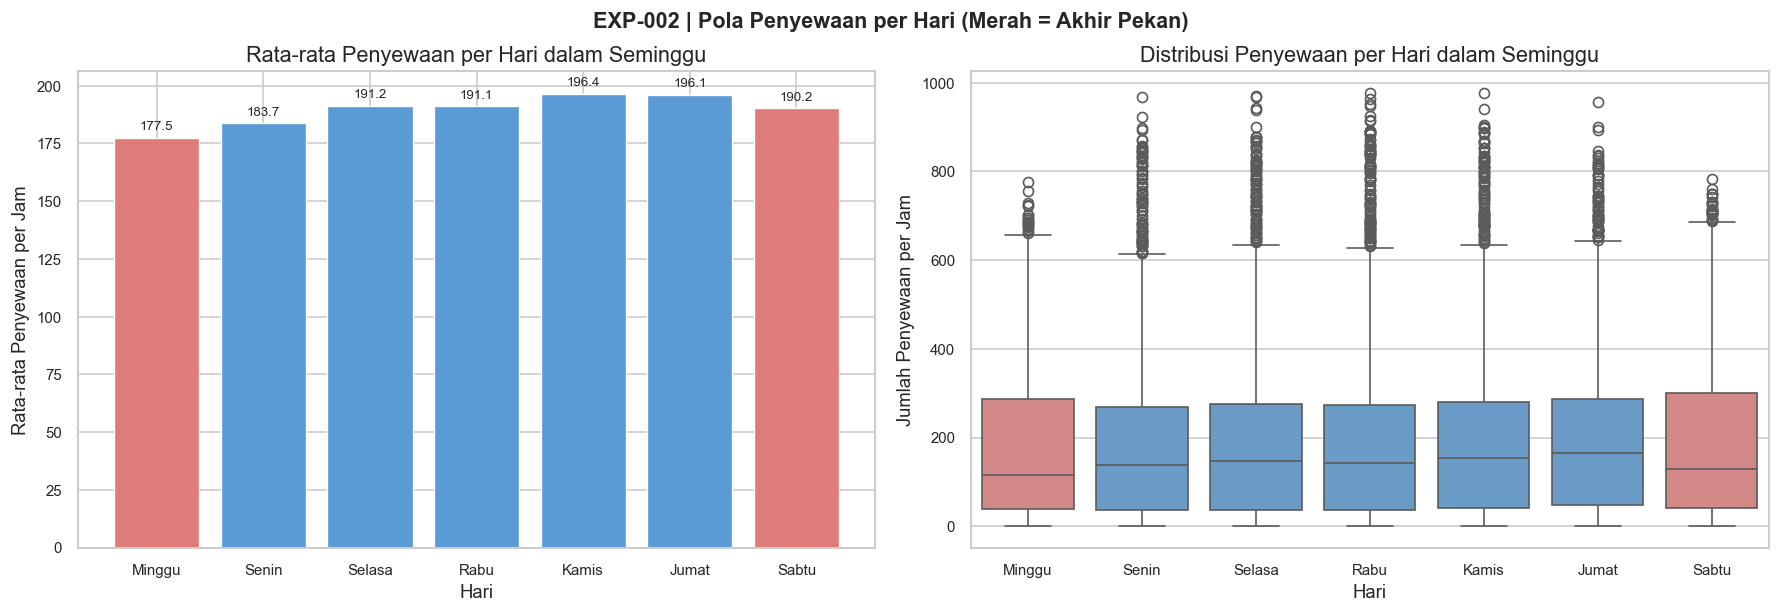

In [9]:
# Rata-rata penyewaan per hari dalam seminggu
urutan_hari = ['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu']

df_weekday = (
    df.groupby('weekday_label')['cnt']
    .agg(['mean', 'median', 'std'])
    .reindex(urutan_hari)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot mean
colors = ['#e07b7b' if d in ['Sabtu', 'Minggu'] else '#5b9bd5' for d in df_weekday['weekday_label']]
bars = axes[0].bar(df_weekday['weekday_label'], df_weekday['mean'],
                   color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Rata-rata Penyewaan per Hari dalam Seminggu')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Rata-rata Penyewaan per Jam')
axes[0].bar_label(bars, fmt='%.1f', fontsize=8, padding=3)

# Boxplot
df_weekday_box = df[['weekday_label', 'cnt']].copy()
df_weekday_box['weekday_label'] = pd.Categorical(df_weekday_box['weekday_label'],
                                                  categories=urutan_hari, ordered=True)
df_weekday_box = df_weekday_box.sort_values('weekday_label')
sns.boxplot(data=df_weekday_box, x='weekday_label', y='cnt', ax=axes[1],
            palette=['#e07b7b' if d in ['Sabtu', 'Minggu'] else '#5b9bd5' for d in urutan_hari])
axes[1].set_title('Distribusi Penyewaan per Hari dalam Seminggu')
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Jumlah Penyewaan per Jam')

plt.tight_layout()
plt.suptitle('EXP-002 | Pola Penyewaan per Hari (Merah = Akhir Pekan)', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_05_pola_weekday.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Rata-rata penyewaan per jam **relatif konsisten** sepanjang minggu.
- Hari kerja (Senin–Jumat) cenderung memiliki rata-rata yang sedikit lebih tinggi dibanding akhir pekan, namun perbedaannya tidak ekstrem.
- Distribusi (boxplot) menunjukkan variasi yang lebih besar pada hari kerja — ini disebabkan oleh pola dua puncak (bimodal) yang khas pada hari kerja.

### 6.4 Pola Per Bulan

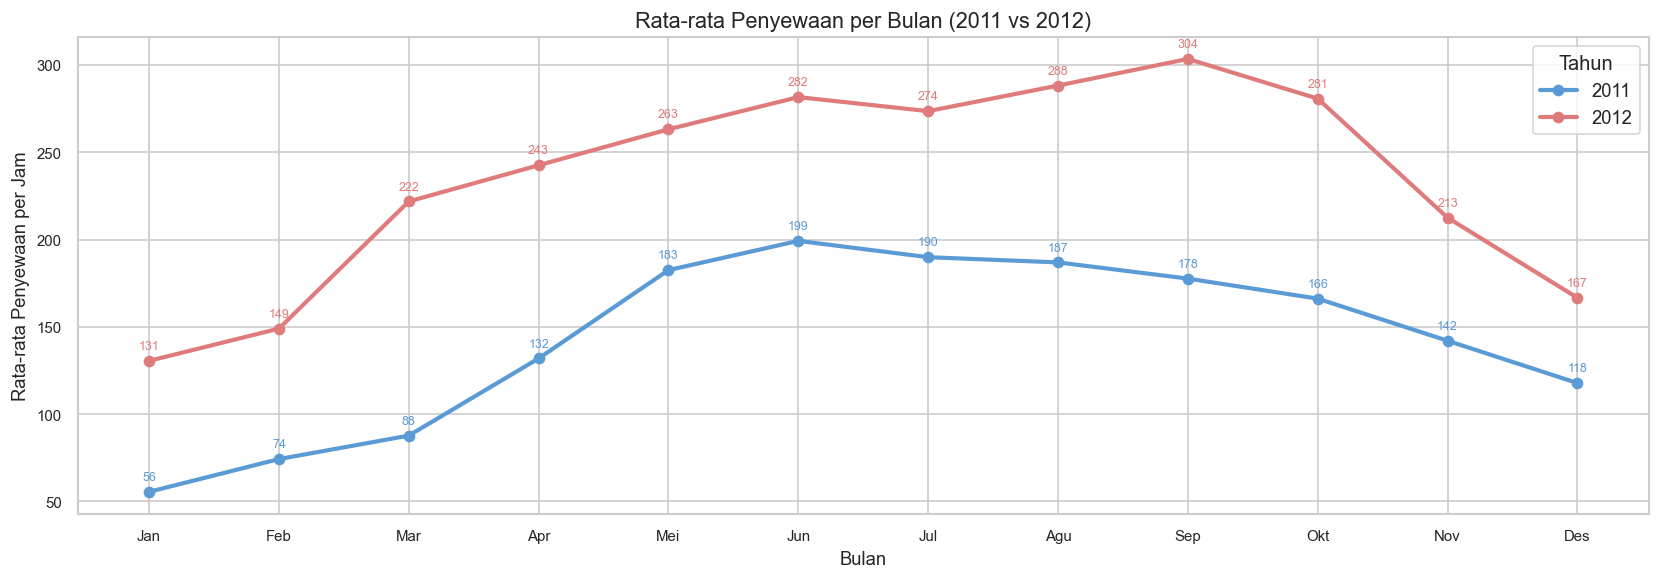

In [10]:
# Rata-rata penyewaan per bulan
nama_bulan = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun',
              7:'Jul', 8:'Agu', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Des'}

df_monthly = df.groupby(['yr_label', 'mnth'])['cnt'].mean().reset_index()
df_monthly['bulan'] = df_monthly['mnth'].map(nama_bulan)

fig, ax = plt.subplots(figsize=(14, 5))

for yr, color in zip(['2011', '2012'], ['#5b9bd5', '#e07b7b']):
    data = df_monthly[df_monthly['yr_label'] == yr]
    ax.plot(data['mnth'], data['cnt'], marker='o', linewidth=2.5,
            label=yr, color=color)
    for _, row in data.iterrows():
        ax.annotate(f'{row["cnt"]:.0f}', (row['mnth'], row['cnt']),
                    textcoords='offset points', xytext=(0, 7),
                    fontsize=7.5, ha='center', color=color)

ax.set_title('Rata-rata Penyewaan per Bulan (2011 vs 2012)')
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata Penyewaan per Jam')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([nama_bulan[i] for i in range(1, 13)])
ax.legend(title='Tahun')

plt.tight_layout()
plt.savefig('../data/eda_06_pola_bulanan.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Terdapat **pola musiman tahunan yang sangat jelas**: penyewaan meningkat dari awal tahun hingga pertengahan tahun (puncak sekitar Juni–September), kemudian menurun menjelang akhir tahun.
- Penyewaan **2012 secara konsisten lebih tinggi** dari 2011 di semua bulan, mengonfirmasi adanya **tren pertumbuhan** antar tahun.
- Bulan Desember–Februari memiliki penyewaan terendah, berkorelasi dengan musim dingin.

### 6.5 Pola per Musim (Season)

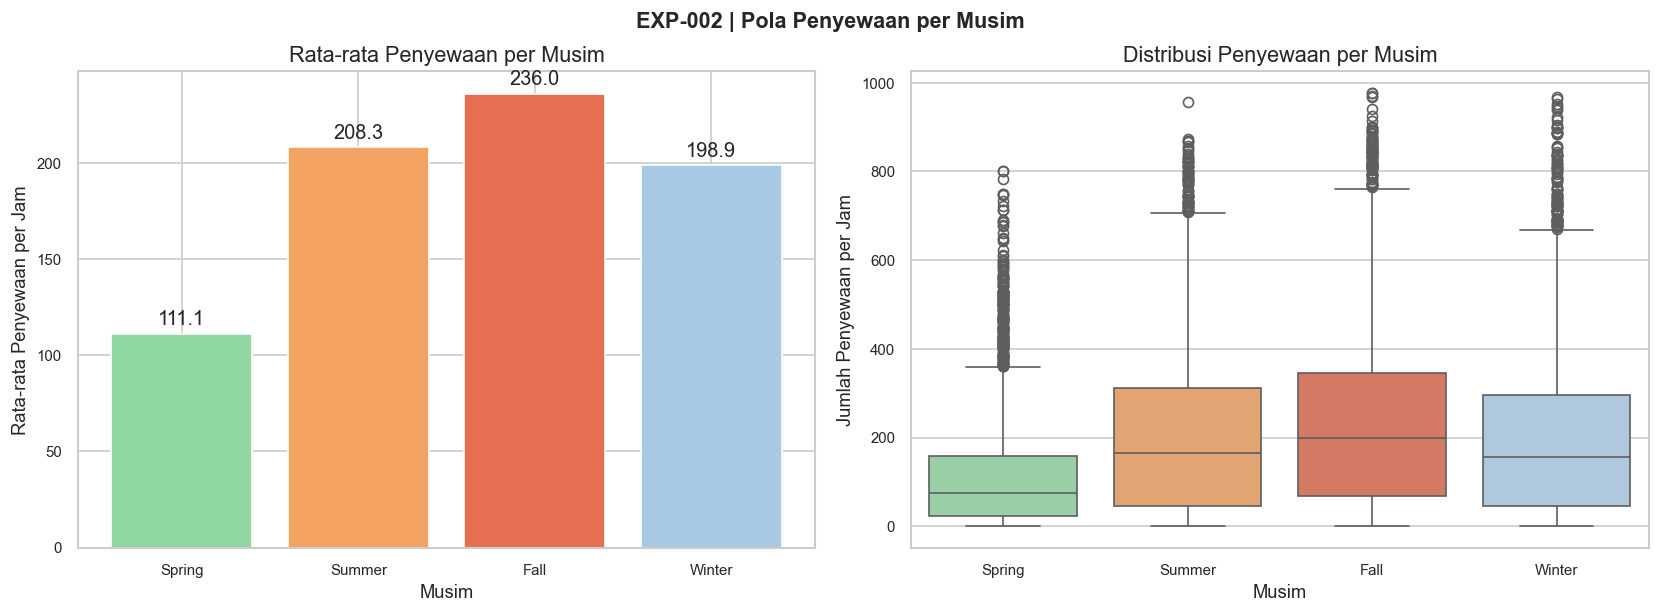

season_label     mean   median     sum
      Spring 111.1146  76.0000  471348
      Summer 208.3441 165.0000  918589
        Fall 236.0162 199.0000 1061129
      Winter 198.8689 155.5000  841613


In [11]:
# Rata-rata penyewaan per musim
urutan_musim = ['Spring', 'Summer', 'Fall', 'Winter']
df_season = (
    df.groupby('season_label')['cnt']
    .agg(['mean', 'median', 'sum'])
    .reindex(urutan_musim)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart rata-rata
palette_musim = ['#90d7a3', '#f4a261', '#e76f51', '#a8c9e4']
bars = axes[0].bar(df_season['season_label'], df_season['mean'],
                   color=palette_musim, edgecolor='white')
axes[0].set_title('Rata-rata Penyewaan per Musim')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Penyewaan per Jam')
axes[0].bar_label(bars, fmt='%.1f', padding=3)

# Boxplot
df_season_box = df[['season_label', 'cnt']].copy()
df_season_box['season_label'] = pd.Categorical(df_season_box['season_label'],
                                               categories=urutan_musim, ordered=True)
df_season_box = df_season_box.sort_values('season_label')
sns.boxplot(data=df_season_box, x='season_label', y='cnt', ax=axes[1],
            palette=palette_musim)
axes[1].set_title('Distribusi Penyewaan per Musim')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Jumlah Penyewaan per Jam')

plt.tight_layout()
plt.suptitle('EXP-002 | Pola Penyewaan per Musim', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_07_pola_musim.png', bbox_inches='tight', dpi=120)
plt.show()

print(df_season[['season_label', 'mean', 'median', 'sum']].to_string(index=False))

**Interpretasi:**

- **Fall (Gugur)** memiliki rata-rata penyewaan tertinggi, diikuti Summer (Panas).
- **Spring (Semi)** memiliki rata-rata penyewaan terendah.
- Urutan dari tinggi ke rendah: Fall > Summer > Winter > Spring.
- Musim dingin (Winter) ternyata memiliki penyewaan lebih tinggi dari musim semi (Spring) — mungkin karena dataset mencakup 2 tahun sehingga data 2012 pada musim dingin (yang lebih tinggi) mengangkat rata-rata.
- Feature `season` merupakan feature yang penting untuk modeling.

---

## 7. Analisis Feature Cuaca

Analisis pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda.

### 7.1 Kondisi Cuaca (Weather Situation)

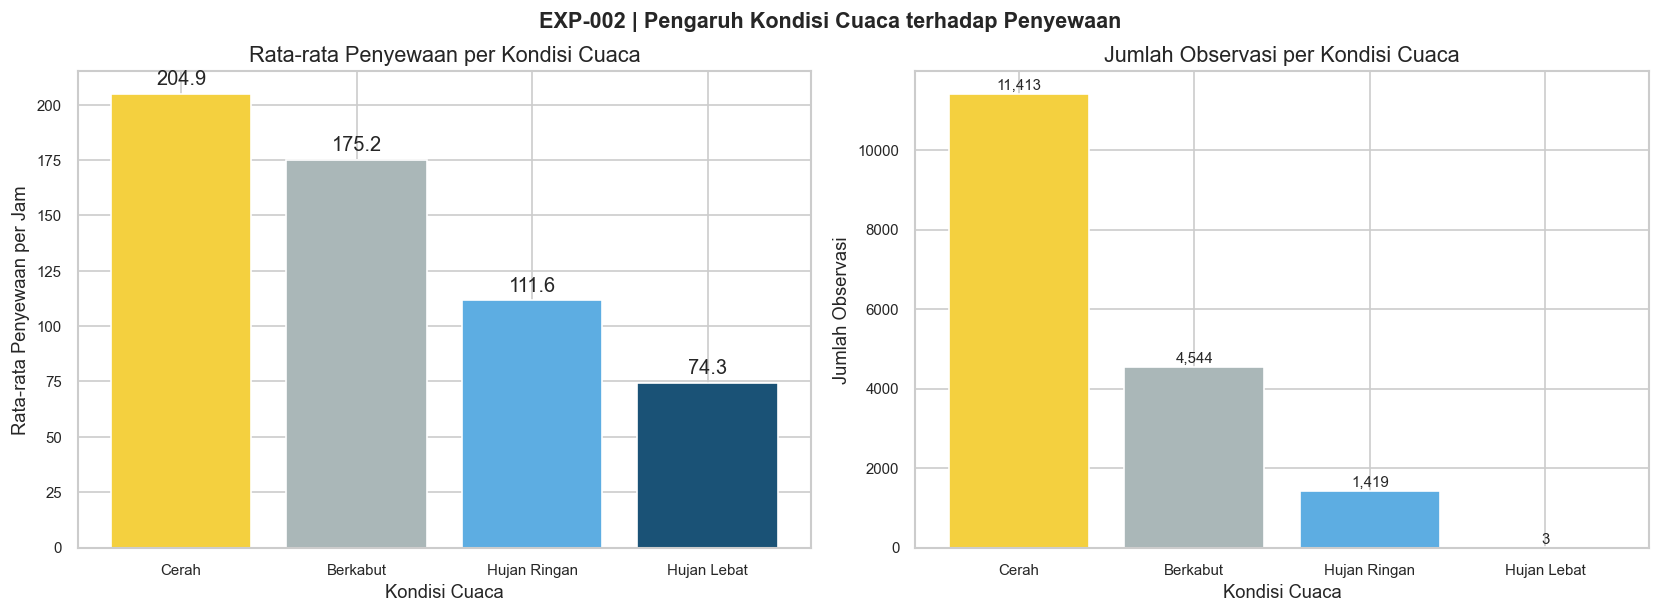

In [12]:
# Distribusi kondisi cuaca
df_weather = (
    df.groupby('weathersit_label')['cnt']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)
urutan_cuaca = ['Cerah', 'Berkabut', 'Hujan Ringan', 'Hujan Lebat']
df_weather['weathersit_label'] = pd.Categorical(df_weather['weathersit_label'],
                                                  categories=urutan_cuaca, ordered=True)
df_weather = df_weather.sort_values('weathersit_label')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar rata-rata penyewaan per kondisi cuaca
palette_cuaca = ['#f4d03f', '#aab7b8', '#5dade2', '#1a5276']
bars = axes[0].bar(df_weather['weathersit_label'], df_weather['mean'],
                   color=palette_cuaca, edgecolor='white')
axes[0].set_title('Rata-rata Penyewaan per Kondisi Cuaca')
axes[0].set_xlabel('Kondisi Cuaca')
axes[0].set_ylabel('Rata-rata Penyewaan per Jam')
axes[0].bar_label(bars, fmt='%.1f', padding=3)

# Jumlah observasi per kondisi cuaca
axes[1].bar(df_weather['weathersit_label'], df_weather['count'],
            color=palette_cuaca, edgecolor='white')
axes[1].set_title('Jumlah Observasi per Kondisi Cuaca')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Jumlah Observasi')
for i, (_, row) in enumerate(df_weather.iterrows()):
    axes[1].text(i, row['count'] + 30, f'{int(row["count"]):,}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('EXP-002 | Pengaruh Kondisi Cuaca terhadap Penyewaan', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_08_kondisi_cuaca.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Cuaca **cerah** menghasilkan penyewaan tertinggi, sedangkan **hujan ringan** menghasilkan penyewaan jauh lebih rendah.
- **Hujan lebat** (weathersit = 4) hampir tidak ada dalam dataset — sangat jarang terjadi.
- Terdapat hubungan **negatif** yang jelas antara keparahan cuaca dan jumlah penyewaan.
- Feature `weathersit` memiliki pengaruh yang signifikan terhadap target.

### 7.2 Suhu vs Penyewaan

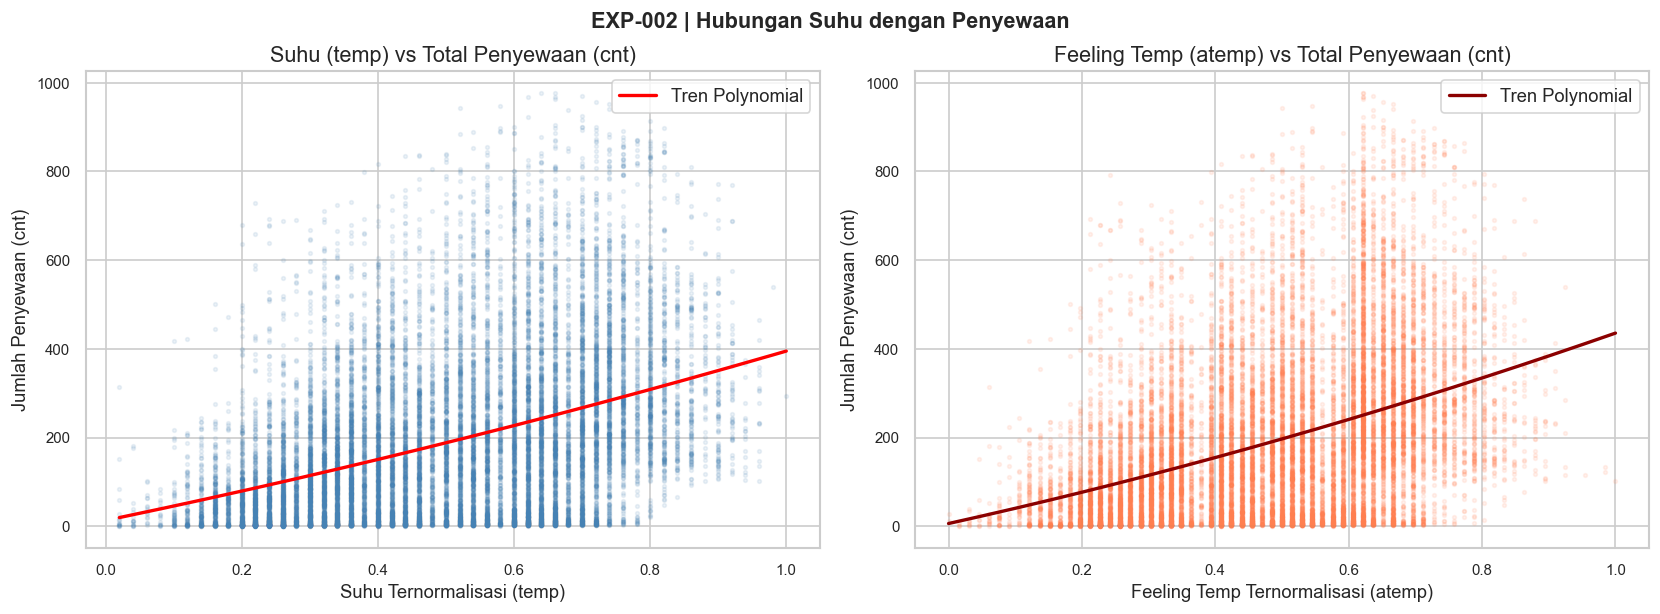

Korelasi temp  vs cnt : 0.4048
Korelasi atemp vs cnt : 0.4009


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot temp vs cnt
axes[0].scatter(df['temp'], df['cnt'], alpha=0.1, color='steelblue', s=5)
# Garis tren
z = np.polyfit(df['temp'], df['cnt'], 2)
p = np.poly1d(z)
x_line = np.linspace(df['temp'].min(), df['temp'].max(), 200)
axes[0].plot(x_line, p(x_line), color='red', linewidth=2, label='Tren Polynomial')
axes[0].set_title('Suhu (temp) vs Total Penyewaan (cnt)')
axes[0].set_xlabel('Suhu Ternormalisasi (temp)')
axes[0].set_ylabel('Jumlah Penyewaan (cnt)')
axes[0].legend()

# Scatter plot atemp vs cnt
axes[1].scatter(df['atemp'], df['cnt'], alpha=0.1, color='coral', s=5)
z2 = np.polyfit(df['atemp'], df['cnt'], 2)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['atemp'].min(), df['atemp'].max(), 200)
axes[1].plot(x_line2, p2(x_line2), color='darkred', linewidth=2, label='Tren Polynomial')
axes[1].set_title('Feeling Temp (atemp) vs Total Penyewaan (cnt)')
axes[1].set_xlabel('Feeling Temp Ternormalisasi (atemp)')
axes[1].set_ylabel('Jumlah Penyewaan (cnt)')
axes[1].legend()

plt.tight_layout()
plt.suptitle('EXP-002 | Hubungan Suhu dengan Penyewaan', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_09_suhu_vs_cnt.png', bbox_inches='tight', dpi=120)
plt.show()

corr_temp  = df['temp'].corr(df['cnt'])
corr_atemp = df['atemp'].corr(df['cnt'])
print(f'Korelasi temp  vs cnt : {corr_temp:.4f}')
print(f'Korelasi atemp vs cnt : {corr_atemp:.4f}')

**Interpretasi:**

- Suhu memiliki **korelasi positif** yang cukup kuat dengan jumlah penyewaan.
- Hubungannya bersifat **non-linear (kuadratik)**: penyewaan meningkat seiring suhu namun ada titik jenuh di suhu sangat tinggi (sangat panas justru mengurangi kenyamanan bersepeda).
- `temp` dan `atemp` memiliki korelasi yang sangat mirip — potensi multikolinearitas yang perlu ditangani saat feature selection.

### 7.3 Kelembapan & Kecepatan Angin vs Penyewaan

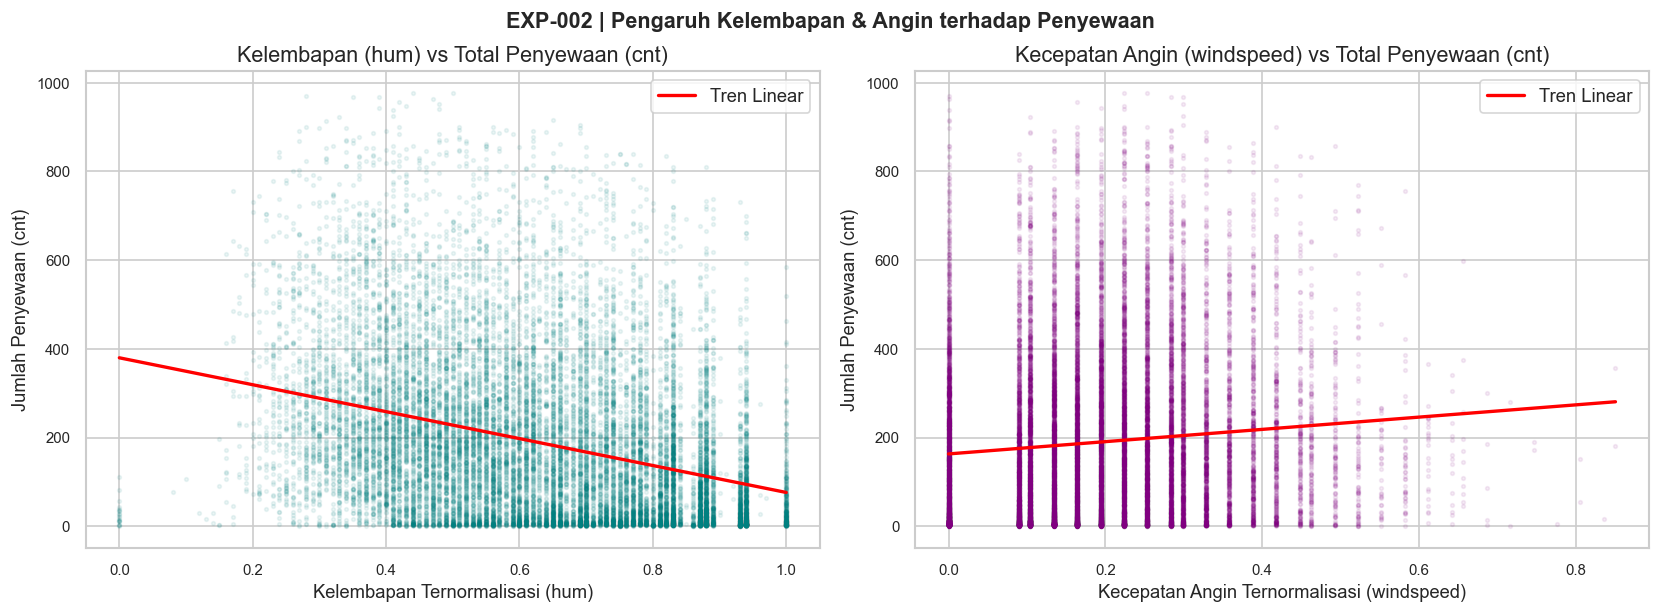

Korelasi hum       vs cnt : -0.3229
Korelasi windspeed vs cnt : 0.0932


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Humidity vs cnt
axes[0].scatter(df['hum'], df['cnt'], alpha=0.08, color='teal', s=5)
z3 = np.polyfit(df['hum'], df['cnt'], 1)
p3 = np.poly1d(z3)
x3 = np.linspace(df['hum'].min(), df['hum'].max(), 200)
axes[0].plot(x3, p3(x3), color='red', linewidth=2, label='Tren Linear')
axes[0].set_title('Kelembapan (hum) vs Total Penyewaan (cnt)')
axes[0].set_xlabel('Kelembapan Ternormalisasi (hum)')
axes[0].set_ylabel('Jumlah Penyewaan (cnt)')
axes[0].legend()

# Windspeed vs cnt
axes[1].scatter(df['windspeed'], df['cnt'], alpha=0.08, color='purple', s=5)
z4 = np.polyfit(df['windspeed'], df['cnt'], 1)
p4 = np.poly1d(z4)
x4 = np.linspace(df['windspeed'].min(), df['windspeed'].max(), 200)
axes[1].plot(x4, p4(x4), color='red', linewidth=2, label='Tren Linear')
axes[1].set_title('Kecepatan Angin (windspeed) vs Total Penyewaan (cnt)')
axes[1].set_xlabel('Kecepatan Angin Ternormalisasi (windspeed)')
axes[1].set_ylabel('Jumlah Penyewaan (cnt)')
axes[1].legend()

plt.tight_layout()
plt.suptitle('EXP-002 | Pengaruh Kelembapan & Angin terhadap Penyewaan', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_10_hum_wind_cnt.png', bbox_inches='tight', dpi=120)
plt.show()

corr_hum   = df['hum'].corr(df['cnt'])
corr_wind  = df['windspeed'].corr(df['cnt'])
print(f'Korelasi hum       vs cnt : {corr_hum:.4f}')
print(f'Korelasi windspeed vs cnt : {corr_wind:.4f}')

**Interpretasi:**

- **Kelembapan (`hum`)** memiliki korelasi **negatif** dengan penyewaan — semakin lembap, semakin sedikit penyewaan. Namun korelasinya relatif lemah.
- **Kecepatan angin (`windspeed`)** memiliki pengaruh yang sangat lemah terhadap penyewaan — scatter plot sangat tersebar tanpa pola yang jelas.
- Di antara seluruh feature cuaca, `temp`/`atemp` adalah yang paling berpengaruh, diikuti `weathersit`, kemudian `hum`, dan terakhir `windspeed`.

---

## 8. Analisis Feature Kategorikal

Analisis pengaruh feature binary dan kategorikal terhadap jumlah penyewaan.

### 8.1 Hari Kerja vs Hari Libur (workingday & holiday)

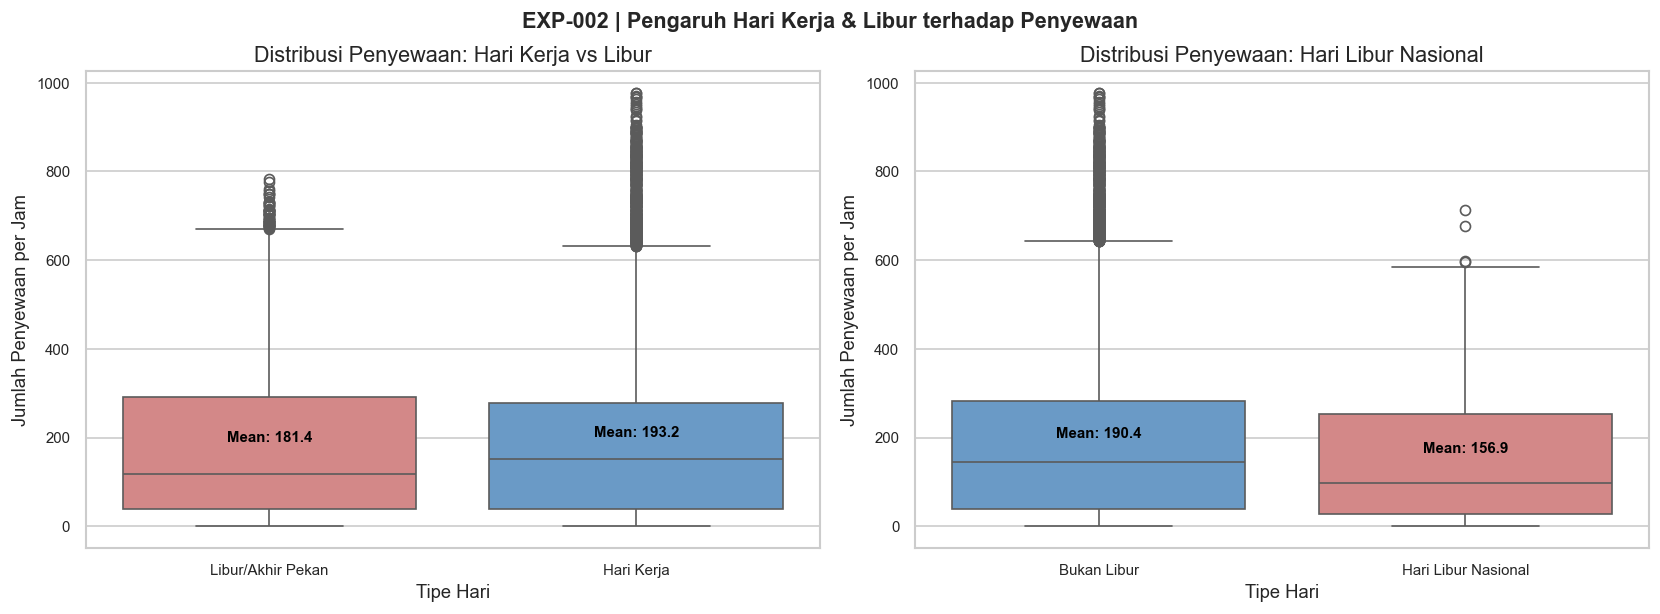

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Working day
df['workingday_label'] = df['workingday'].map({0: 'Libur/Akhir Pekan', 1: 'Hari Kerja'})
sns.boxplot(data=df, x='workingday_label', y='cnt', ax=axes[0],
            palette=['#e07b7b', '#5b9bd5'])
axes[0].set_title('Distribusi Penyewaan: Hari Kerja vs Libur')
axes[0].set_xlabel('Tipe Hari')
axes[0].set_ylabel('Jumlah Penyewaan per Jam')

# Annotasi rata-rata
for i, label in enumerate(['Libur/Akhir Pekan', 'Hari Kerja']):
    mean_val = df[df['workingday_label'] == label]['cnt'].mean()
    axes[0].text(i, mean_val + 10, f'Mean: {mean_val:.1f}',
                 ha='center', fontsize=9, color='black', fontweight='bold')

# Holiday
df['holiday_label'] = df['holiday'].map({0: 'Bukan Libur', 1: 'Hari Libur Nasional'})
sns.boxplot(data=df, x='holiday_label', y='cnt', ax=axes[1],
            palette=['#5b9bd5', '#e07b7b'])
axes[1].set_title('Distribusi Penyewaan: Hari Libur Nasional')
axes[1].set_xlabel('Tipe Hari')
axes[1].set_ylabel('Jumlah Penyewaan per Jam')

for i, label in enumerate(['Bukan Libur', 'Hari Libur Nasional']):
    mean_val = df[df['holiday_label'] == label]['cnt'].mean()
    axes[1].text(i, mean_val + 10, f'Mean: {mean_val:.1f}',
                 ha='center', fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.suptitle('EXP-002 | Pengaruh Hari Kerja & Libur terhadap Penyewaan', fontsize=13, y=1.02, fontweight='bold')
plt.savefig('../data/eda_11_workingday_holiday.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Rata-rata penyewaan antara hari kerja dan hari libur/akhir pekan terlihat **tidak berbeda jauh** secara keseluruhan.
- Namun **pola per jam sangat berbeda** (lihat Section 6.2) — hari kerja bimodal, hari libur unimodal.
- Hari libur nasional (`holiday = 1`) memiliki rata-rata penyewaan yang **sedikit lebih rendah** dari hari biasa, mengindikasikan pengguna lebih sedikit bersepeda saat libur nasional dibanding akhir pekan biasa.

### 8.2 Pola Jam per Musim (Heatmap)

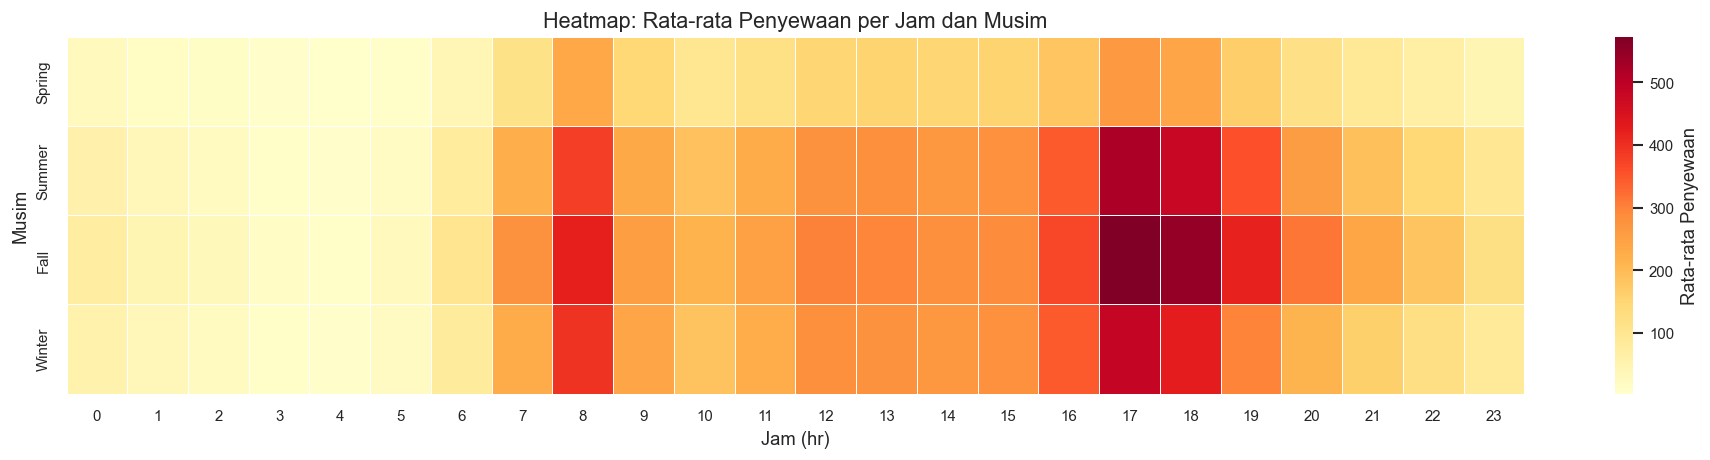

In [16]:
# Heatmap: pola rata-rata penyewaan per jam dan musim
pivot_season_hr = df.pivot_table(
    values='cnt', index='season_label', columns='hr', aggfunc='mean'
).reindex(['Spring', 'Summer', 'Fall', 'Winter'])

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot_season_hr, cmap='YlOrRd', annot=False, fmt='.0f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Rata-rata Penyewaan'})
ax.set_title('Heatmap: Rata-rata Penyewaan per Jam dan Musim')
ax.set_xlabel('Jam (hr)')
ax.set_ylabel('Musim')

plt.tight_layout()
plt.savefig('../data/eda_12_heatmap_season_hr.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Pola bimodal (pagi & sore) terlihat jelas pada **semua musim**, namun intensitasnya berbeda — musim gugur (Fall) dan panas (Summer) memiliki nilai paling tinggi.
- Pola musim semi (Spring) paling lemah di semua jam.
- Heatmap ini mengonfirmasi bahwa interaksi `hr × season` sangat informatif untuk modeling.

### 8.3 Pola Jam per Tipe Hari (Heatmap)

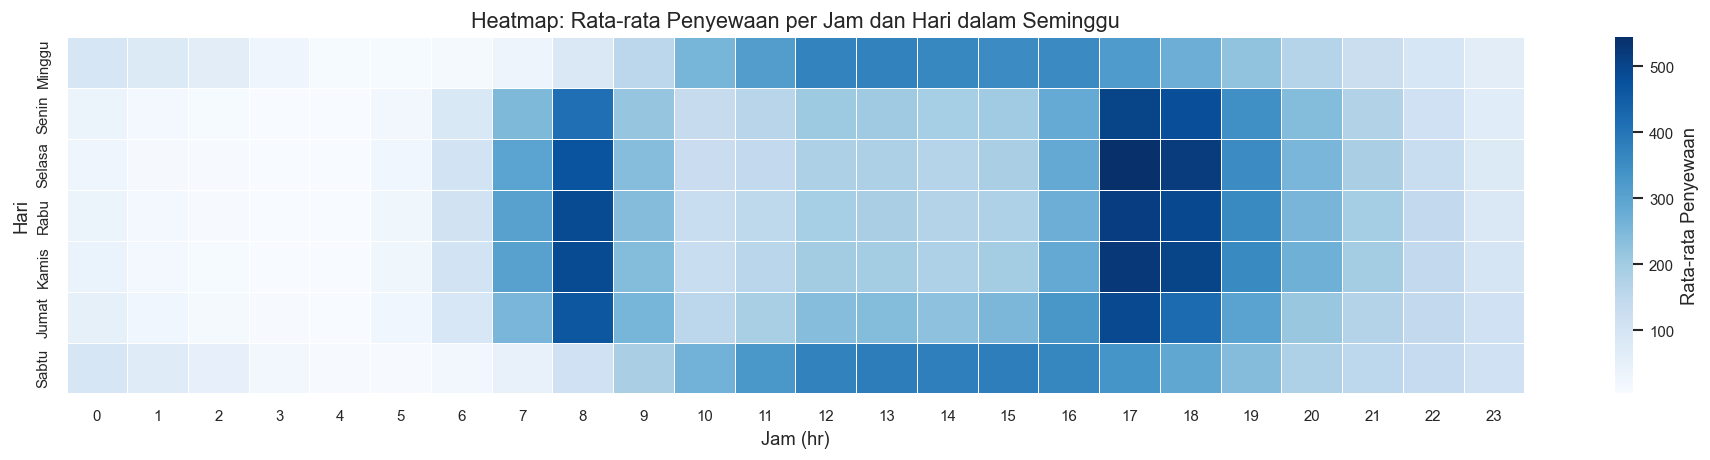

In [17]:
# Heatmap: pola rata-rata penyewaan per jam dan weekday
urutan_hari = ['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu']

pivot_weekday_hr = df.pivot_table(
    values='cnt', index='weekday_label', columns='hr', aggfunc='mean'
).reindex(urutan_hari)

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot_weekday_hr, cmap='Blues', annot=False,
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Rata-rata Penyewaan'})
ax.set_title('Heatmap: Rata-rata Penyewaan per Jam dan Hari dalam Seminggu')
ax.set_xlabel('Jam (hr)')
ax.set_ylabel('Hari')

plt.tight_layout()
plt.savefig('../data/eda_13_heatmap_weekday_hr.png', bbox_inches='tight', dpi=120)
plt.show()

**Interpretasi:**

- Heatmap ini secara visual memisahkan dua pola yang berbeda:
  - **Hari kerja (Senin–Jumat)**: Dua titik panas yang jelas di jam 08:00 dan 17:00–18:00.
  - **Akhir pekan (Sabtu–Minggu)**: Satu area panas yang lebih luas di siang hari (10:00–15:00).
- Visualisasi ini sangat berguna untuk mendukung pembuatan **interaction feature** `hr × workingday` pada tahap Feature Engineering.

---

## 9. Analisis Korelasi

Menganalisis hubungan linear antar seluruh feature numerik menggunakan Pearson Correlation.

### 9.1 Correlation Matrix

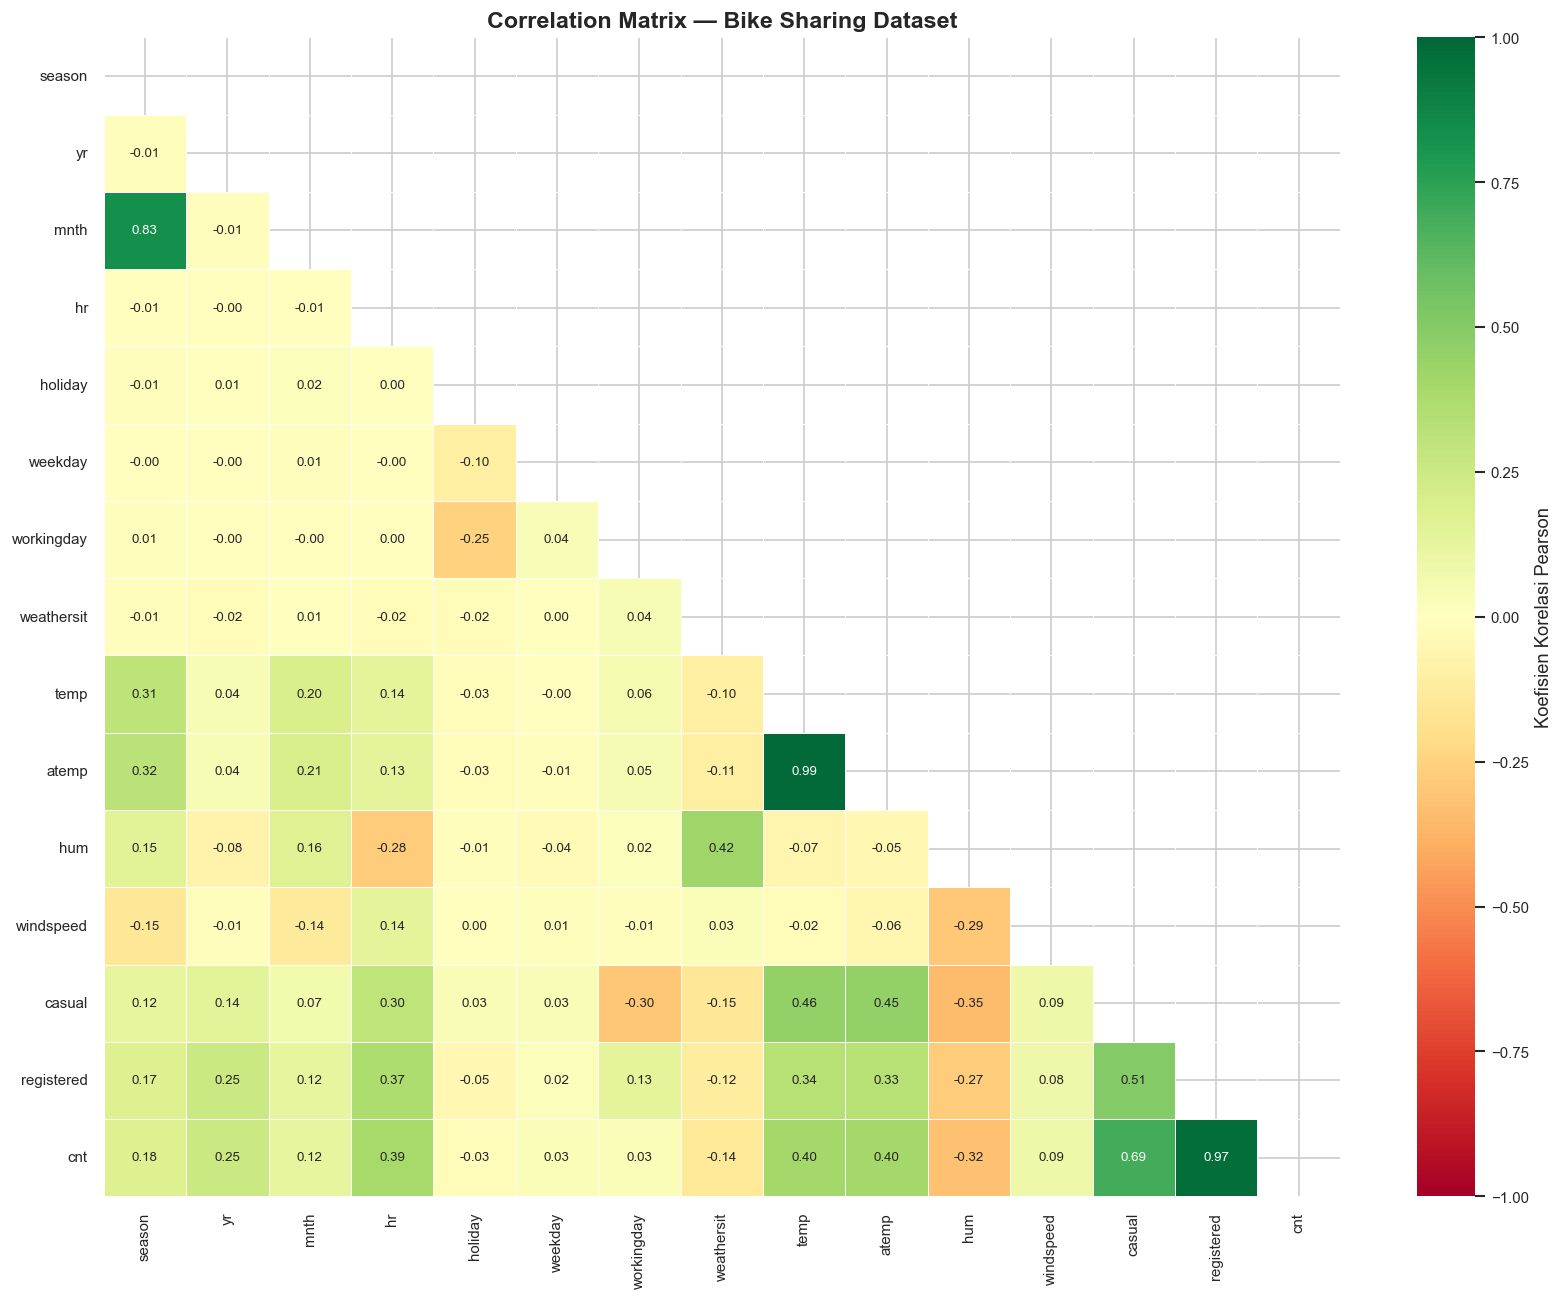

In [18]:
# Kolom yang dianalisis korelasinya
kolom_korelasi = [
    'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'atemp', 'hum',
    'windspeed', 'casual', 'registered', 'cnt'
]

corr_matrix = df[kolom_korelasi].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 8},
    cbar_kws={'label': 'Koefisien Korelasi Pearson'}
)
ax.set_title('Correlation Matrix — Bike Sharing Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/eda_14_correlation_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

### 9.2 Korelasi Feature terhadap Target (cnt)

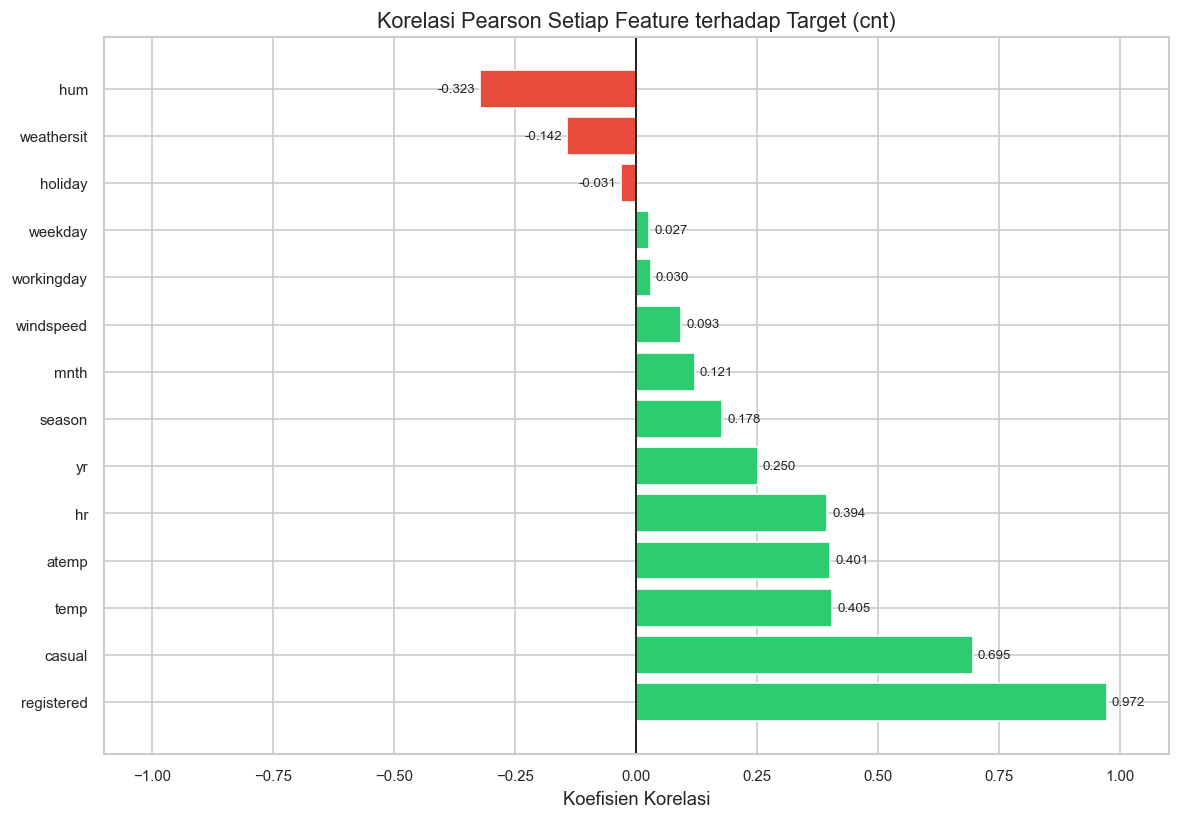


Korelasi Feature terhadap cnt (diurutkan dari tertinggi ke terendah):
  registered   : +0.9722 (+)
  casual       : +0.6946 (+)
  temp         : +0.4048 (+)
  atemp        : +0.4009 (+)
  hr           : +0.3941 (+)
  yr           : +0.2505 (+)
  season       : +0.1781 (+)
  mnth         : +0.1206 (+)
  windspeed    : +0.0932 (+)
  workingday   : +0.0303 (+)
  weekday      : +0.0269 (+)
  holiday      : -0.0309 (-)
  weathersit   : -0.1424 (-)
  hum          : -0.3229 (-)


In [19]:
# Korelasi setiap feature terhadap cnt
corr_with_cnt = corr_matrix['cnt'].drop('cnt').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_cnt.values]
bars = ax.barh(corr_with_cnt.index, corr_with_cnt.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Korelasi Pearson Setiap Feature terhadap Target (cnt)')
ax.set_xlabel('Koefisien Korelasi')
ax.set_xlim(-1.1, 1.1)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('../data/eda_15_korelasi_vs_cnt.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nKorelasi Feature terhadap cnt (diurutkan dari tertinggi ke terendah):')
for feat, val in corr_with_cnt.items():
    arah = '(+)' if val > 0 else '(-)'
    print(f'  {feat:<12} : {val:+.4f} {arah}')

**Interpretasi:**

Feature yang paling berkorelasi dengan target `cnt`:

| Peringkat | Feature | Korelasi | Keterangan |
|-----------|---------|----------|------------|
| 1 | `registered` | ~0.97 | Bukan feature model (data leakage) |
| 2 | `casual` | ~0.69 | Bukan feature model (data leakage) |
| 3 | `hr` | ~0.40 | ✅ Feature paling penting untuk model |
| 4 | `temp` | ~0.40 | ✅ Feature cuaca terpenting |
| 5 | `atemp` | ~0.40 | ✅ Sangat berkorelasi dengan temp |
| 6 | `season` | ~0.18 | ✅ Feature musiman |
| 7 | `yr` | ~0.25 | ✅ Tren antar tahun |
| 8 | `mnth` | ~0.21 | ✅ Feature bulanan |
| 9 | `hum` | ~-0.32 | ✅ Korelasi negatif |
| 10 | `weathersit` | ~-0.14 | ✅ Korelasi negatif |

Setelah mengecualikan `casual` dan `registered` (data leakage), **`hr` dan `temp`** adalah feature yang paling berkorelasi dengan target.

---

## 10. EDA Summary & Insight

### 10.1 Hipotesis Terkonfirmasi

> ✅ **Hipotesis terkonfirmasi**: Dataset memiliki pola musiman dan pola harian yang memengaruhi jumlah penyewaan sepeda.

Kedua pola tersebut terbukti secara visual dan kuantitatif:
- Pola harian: dua puncak pada jam 08:00 dan 17:00 di hari kerja.
- Pola musiman: penyewaan tertinggi di Fall/Summer, terendah di Spring/Winter.

---

### 10.2 Insight per Kelompok Feature

#### 📌 Target (cnt)
- Distribusi `cnt` bersifat **right-skewed** dengan rentang lebar (1–977).
- Variasi sangat tinggi — perlu feature yang informatif untuk model dapat memprediksi dengan baik.
- Transformasi log pada target dapat dipertimbangkan saat preprocessing.

#### 📌 Time Features
- `hr` adalah **feature terpenting**: pola bimodal (08:00 & 17:00) di hari kerja, unimodal (siang) di akhir pekan.
- `mnth` dan `season` menangkap pola musiman tahunan dengan jelas.
- `yr` merekam tren pertumbuhan yang signifikan dari 2011 ke 2012.

#### 📌 Calendar Features
- `workingday` sangat memengaruhi **pola harian** (bukan rata-rata total).
- Interaksi `hr × workingday` sangat informatif dan merupakan kandidat feature engineering.

#### 📌 Weather Features
- `temp`/`atemp` berkorelasi positif dengan penyewaan (hubungan non-linear).
- `hum` berkorelasi negatif lemah.
- `windspeed` pengaruhnya minimal.
- `weathersit` menunjukkan penurunan penyewaan yang signifikan saat cuaca buruk.

#### 📌 Korelasi
- `temp` dan `atemp` berkorelasi sangat tinggi satu sama lain → potensi **multikolinearitas**.
- Setelah mengecualikan leakage features, `hr` dan `temp` adalah predictor terkuat.

---

### 10.3 Daftar Feature Penting untuk Modeling

| Prioritas | Feature | Alasan |
|-----------|---------|--------|
| ⭐⭐⭐ | `hr` | Korelasi tertinggi, pola jam sangat kuat |
| ⭐⭐⭐ | `temp` | Korelasi positif kuat dengan target |
| ⭐⭐⭐ | `season` | Pola musiman yang jelas |
| ⭐⭐⭐ | `yr` | Menangkap tren pertumbuhan |
| ⭐⭐ | `mnth` | Granularitas bulanan dari pola musiman |
| ⭐⭐ | `workingday` | Penentu pola harian |
| ⭐⭐ | `weathersit` | Pengaruh kondisi cuaca |
| ⭐⭐ | `hum` | Korelasi negatif dengan target |
| ⭐ | `weekday` | Berguna untuk interaksi dengan hr |
| ⭐ | `holiday` | Pengaruh kecil tapi informatif |
| ⭐ | `atemp` | Redundan dengan temp, tapi bisa saling menggantikan |
| ⭐ | `windspeed` | Pengaruh minimal |

---

### 10.4 Rekomendasi Feature Engineering

Berdasarkan EDA ini, berikut adalah potensi feature engineering yang akan dieksplorasi pada EXP-004:

1. **Interaction Feature**: `hr × workingday` — membedakan pola hari kerja vs libur per jam.
2. **Cyclical Encoding**: `hr`, `mnth`, `weekday` menggunakan `sin`/`cos` agar model memahami sifat siklus waktu.
3. **Suhu Aktual**: Menghitung suhu aktual dari nilai ternormalisasi (`temp × 41`).
4. **Peak Hour Flag**: Feature biner yang menandai jam sibuk (07:00–09:00, 16:00–19:00).
5. **Weekend Flag**: Feature biner `is_weekend` dari `weekday`.
6. **Quarter**: Kuartal tahun yang lebih kasar dari bulan.
7. **Log Transform Target**: Transformasi `log(cnt)` untuk menangani skewness.

---

## 11. Next Step

---

### Eksperimen Berikutnya

| Informasi | Detail |
|-----------|--------|
| **ID** | EXP-003 |
| **Nama** | Data Cleaning |
| **Notebook** | `03_preprocessing.ipynb` |

**Tujuan:**

> Memastikan dataset siap digunakan untuk proses feature engineering dan modeling.

**Aktivitas yang akan dilakukan pada EXP-003:**

- Konversi tipe data `dteday` ke `datetime` secara resmi
- Validasi ulang missing value dan duplicate
- Penanganan outlier pada `cnt` (berdasarkan hasil EDA)
- Penghapusan kolom yang tidak digunakan (`instant`, `casual`, `registered`)
- Validasi rentang nilai kolom kategorikal
- Menyimpan dataset bersih ke `data/processed_data.csv`

---

*Notebook EXP-002 Exploratory Data Analysis — Selesai.*